Logistic regression training set accuracy: 0.7128309572301426
Logistic regression test set accuracy: 0.68
Best RF params: {'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 20}
Best RF score: 0.615, R2 on test set: 0.696
8.0Hz, 102 samples, Acc: 0.550
              precision    recall  f1-score   support

           0       0.67      0.20      0.31        10
           1       0.53      0.90      0.67        10

    accuracy                           0.55        20
   macro avg       0.60      0.55      0.49        20
weighted avg       0.60      0.55      0.49        20

11.3Hz, 103 samples, Acc: 0.762
              precision    recall  f1-score   support

           0       0.73      0.80      0.76        10
           1       0.80      0.73      0.76        11

    accuracy                           0.76        21
   macro avg       0.76      0.76      0.76        21
weighted avg       0.77      0.76      0.76  

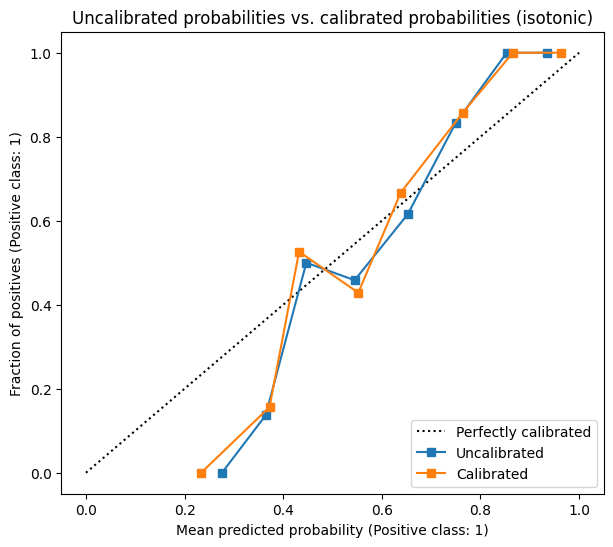

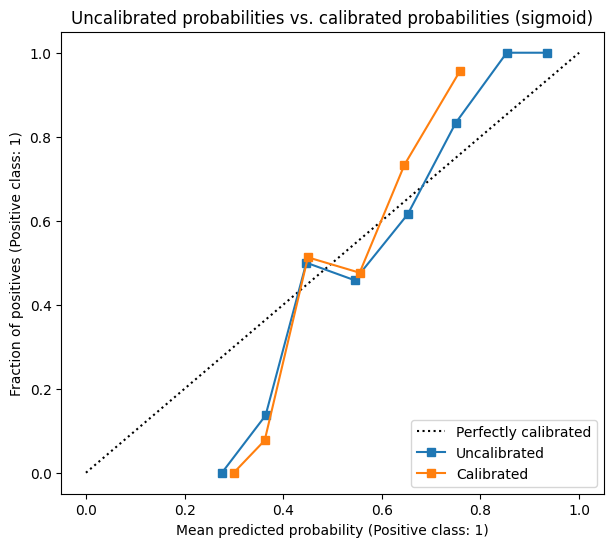

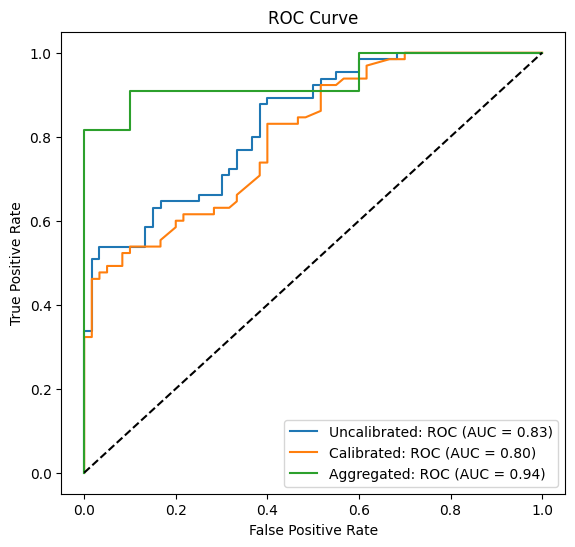

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.367, R2 on test set: 0.615


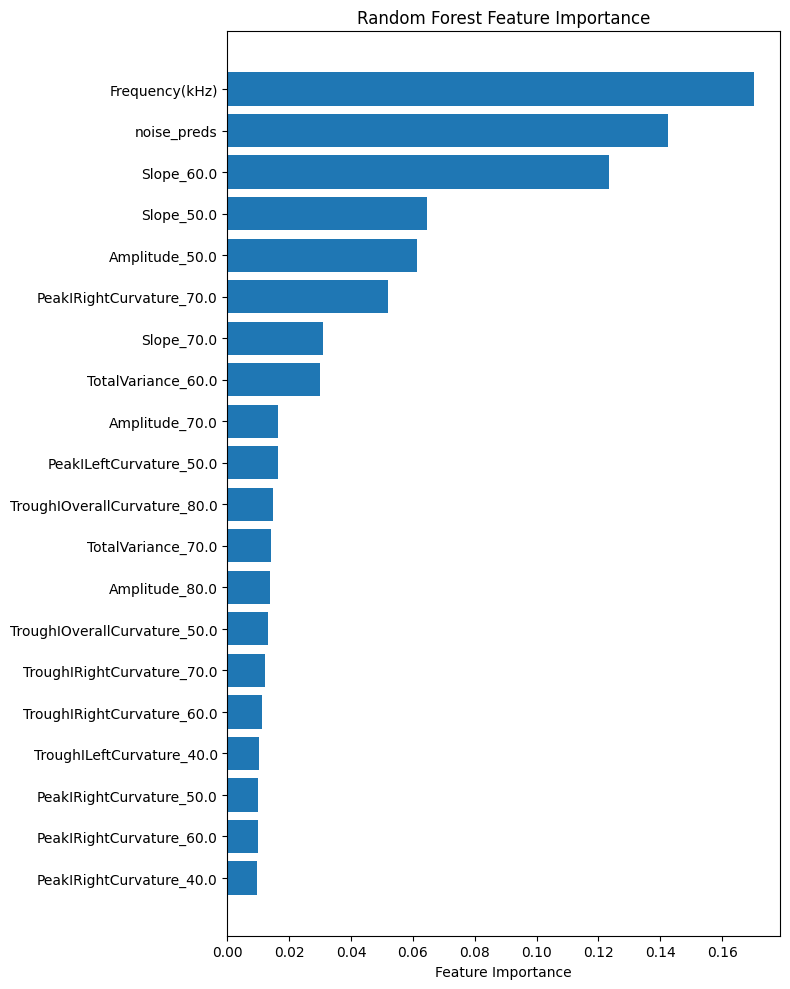

8.0Hz, 102 samples, R2: 0.018, RMSE: 1.005
11.3Hz, 103 samples, R2: -0.071, RMSE: 1.166
16.0Hz, 103 samples, R2: -0.027, RMSE: 1.284
22.6Hz, 103 samples, R2: 0.755, RMSE: 2.038
32.0Hz, 105 samples, R2: 0.498, RMSE: 3.207
45.2Hz, 100 samples, R2: 0.522, RMSE: 3.173
All data, 616 samples, R2: 0.615, RMSE: 2.184


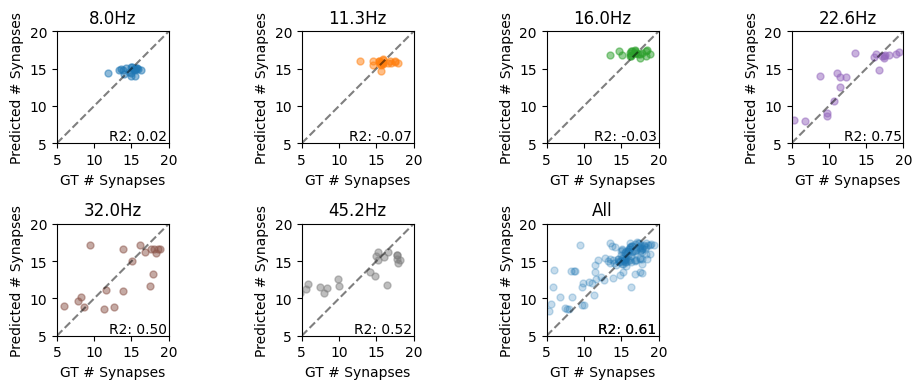

Best RF params: {'clf__max_depth': 2, 'clf__n_estimators': 25}
Best RF score: 0.326, R2 on test set: 0.646
8.0Hz, 102 samples, R2: -0.073, RMSE: 1.050
11.3Hz, 103 samples, R2: -0.237, RMSE: 1.254
16.0Hz, 103 samples, R2: -0.144, RMSE: 1.355
22.6Hz, 103 samples, R2: 0.766, RMSE: 1.990
32.0Hz, 105 samples, R2: 0.527, RMSE: 3.115
45.2Hz, 100 samples, R2: 0.479, RMSE: 3.312
All data, 616 samples, R2: 0.646, RMSE: 2.093


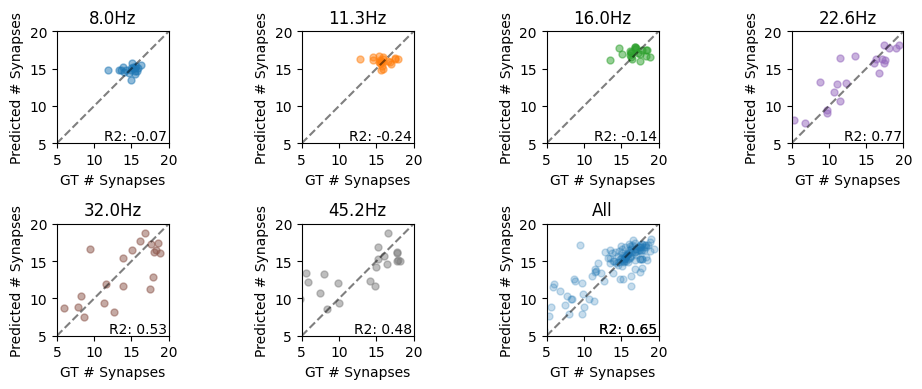

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.388, R2 on test set: 0.690
8.0Hz, 102 samples, R2: 0.048, RMSE: 0.989
11.3Hz, 103 samples, R2: -0.106, RMSE: 1.185
16.0Hz, 103 samples, R2: -0.043, RMSE: 1.294
22.6Hz, 103 samples, R2: 0.728, RMSE: 2.145
32.0Hz, 105 samples, R2: 0.584, RMSE: 2.921
45.2Hz, 100 samples, R2: 0.754, RMSE: 2.278
All data, 616 samples, R2: 0.690, RMSE: 1.960


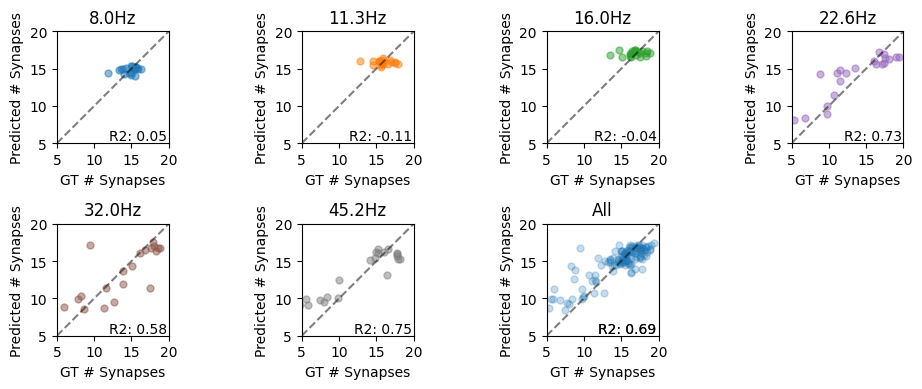

Best RF params: {'clf__max_depth': 2, 'clf__n_estimators': 25}
Best RF score: 0.399, R2 on test set: 0.694
8.0Hz, 102 samples, R2: -0.142, RMSE: 1.083
11.3Hz, 103 samples, R2: -0.237, RMSE: 1.254
16.0Hz, 103 samples, R2: -0.218, RMSE: 1.398
22.6Hz, 103 samples, R2: 0.867, RMSE: 1.498
32.0Hz, 105 samples, R2: 0.574, RMSE: 2.953
45.2Hz, 100 samples, R2: 0.873, RMSE: 1.634
All data, 616 samples, R2: 0.694, RMSE: 1.945


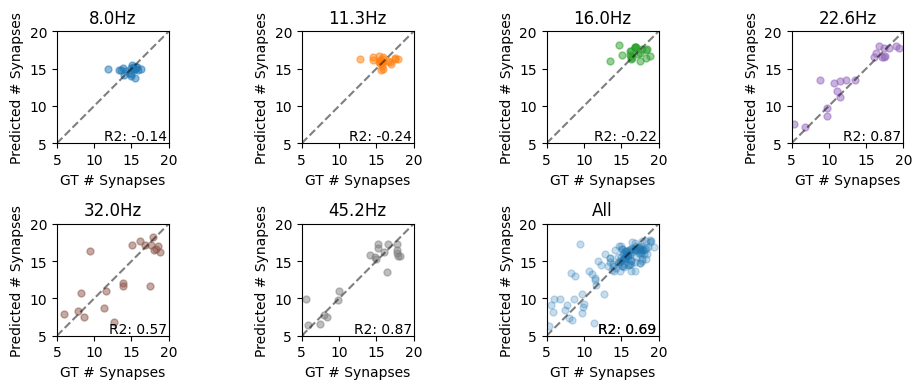

In [1]:
# %run preds_dict.ipynb
%run noise_classifier_clean.ipynb

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# from utils.utils import *
from utils.data_loader import load_data

# Loading data

In [3]:
final_clean_strained = load_data(db_level=0)

In [4]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)
# final_clean_strained = final_clean_strained[final_clean_strained["Level(dB)"] % 2 == 0]

In [5]:
odd_levels = final_clean_strained[
    (final_clean_strained["Level(dB)"] % 2 != 0)
    & (final_clean_strained["Level(dB)"] > 60)
]
len(odd_levels["Subject"].unique())

62

In [6]:
final_clean_strained = (
    final_clean_strained.groupby(["Subject", "Frequency(kHz)", "Level(dB)"])
    .agg(
        {
            "Amplitude": "mean",
            "SynapsesPerIHC": "mean",
            "IHCs": "mean",
            "OrphansPerIHC": "mean",
            "Waveform": "first",
            "WaveI": "first",
            "Peaks": "first",
            "Troughs": "first",
            "Strain": "first",
            "Sex": "first",
            "Group": "first",
            "Noise": "mean",
            "Time (str)": "first",
            "Time (hrs)": "first",
            "Strain (binary)": "first",
            "PeakI Left Curvature": "first",
            "PeakI Overall Curvature": "first",
            "PeakI Right Curvature": "first",
            "TroughI Left Curvature": "first",
            "TroughI Overall Curvature": "first",
            "TroughI Right Curvature": "first",
            "Slope": "first",
            "Distance": "first",
            "Total Variance": "first",
        }
    )
    .reset_index()
)
final_clean_strained["Noise_pred"] = final_clean_strained["Subject"].replace(
    preds_dict
)
final_clean_strained["Noise_cat"] = [
    0 if x else 1 for x in (final_clean_strained["Noise"] < 0.91)
]

In [7]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            (
                "cat",
                OneHotEncoder(drop="first", sparse_output=False),
                cat_features,
            ),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [13]:
final_clean_strained_70 = final_clean_strained[
    final_clean_strained["Level(dB)"] == 70
]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Frequency(kHz)", "Strain (binary)"]
log_features = [
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Noise_pred", "Time (hrs)"]
all_features = num_features + cat_features + log_features + minmax_features
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70,
    num_features,
    cat_features,
    log_features,
    minmax_features,
)

In [10]:
y_train_mean = y_train.mean()

In [11]:
filtered = final_clean_strained[
    (final_clean_strained["Level(dB)"] == 80)
    & (
        (final_clean_strained["Frequency(kHz)"] == 16.0)
        | (final_clean_strained["Frequency(kHz)"] == 32.0)
    )
]

# Lasso

In [14]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("lasso_cv", LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)


print(f"Lasso training set score: {pipeline.score(X_train, y_train)}")
print(f"Lasso test set score: {pipeline.score(X_test, y_test)}")

Lasso training set score: 0.40599331669024885
Lasso test set score: 0.36482920802008567


In [ ]:
final_clean_strained_70 = final_clean_strained[
    (final_clean_strained["Level(dB)"] == 80)
]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Noise", "Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained_70,
    num_features,
    cat_features,
    log_features,
    minmax_features,
)

ValueError: The test_size = 15 should be greater or equal to the number of classes = 16

In [ ]:
import statsmodels.formula.api as smf
final_clean_strained_70 = final_clean_strained[
    (final_clean_strained["Level(dB)"] == 80)
    & (final_clean_strained["Frequency(kHz)"] < 16.0)
]
model = smf.ols(
    ("SynapsesPerIHC ~ Amplitude"), data=final_clean_strained_70
).fit()
model.summary()
preds = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - preds) ** 2))

In [54]:
final_clean_strained_70 = final_clean_strained[
    (final_clean_strained["Level(dB)"] == 80)
    & (final_clean_strained["Frequency(kHz)"] < 16.0)
]
model = smf.ols(
    ("SynapsesPerIHC ~ Amplitude"),
    data=final_clean_strained_70,
).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         SynapsesPerIHC   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     14.78
Date:                Mon, 09 Mar 2026   Prob (F-statistic):           0.000162
Time:                        17:09:06   Log-Likelihood:                -347.69
No. Observations:                 205   AIC:                             699.4
Df Residuals:                     203   BIC:                             706.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     14.4099      0.241     59.889      0.000      13.935      14.884
Amplitude      0.5865      0.153      3.844      0.000       0.286       0.887
==============================================================================
Omnibus:                       42.967   Durbin-Watson:                   1.422
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               81.675
Skew:                          -1.033   Prob(JB):                     1.84e-18
Kurtosis:                       5.300   Cond. No.                         5.57
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
rmse

3.193818418155509

In [15]:
preds = pipeline.predict(X_test)
np.sqrt(np.mean((y_test - preds) ** 2))

2.625223270597153

In [ ]:
features = X_train.columns
coefs = pipeline.named_steps["lasso_cv"].coef_
count = len(coefs[coefs != 0])
print(f"{count} features were selected")
print(f"Dropped features: {features[coefs == 0].values}")

16 features were selected


IndexError: boolean index did not match indexed array along dimension 0; dimension is 15 but corresponding boolean dimension is 19

# Random Forest

In [15]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 200, 300, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(random_state=1)),
    ]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 'log2', 'rf__max_depth': 30}
Best RF score: 0.425, R2 on test set: 0.510


In [16]:
def plot_results(x, y, alpha=0.2, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")

In [17]:
from sklearn.metrics import r2_score


def train_plot_result_frequency_grouped(df, rf_pipeline):
    df = split_by_mouse(df)
    X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
        df, num_features, cat_features, log_features, minmax_features
    )
    freqs = sorted(X_train["Frequency(kHz)"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features + minmax_features
        data = df[df["Frequency(kHz)"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            test = data[data.DataGroup == "Test"].copy()
            test["preds"] = rf_pipeline.predict(X_test1)
            grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
                {"SynapsesPerIHC": "mean", "preds": "mean"}
            )
            r2 = r2_score(
                grouped_preds["SynapsesPerIHC"], grouped_preds["preds"]
            )
            rmse = np.sqrt(
                np.mean(
                    (grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"])
                    ** 2
                )
            )
            print(
                f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
            )
            plt.subplot(2, 4, i + 1)
            plot_results(
                grouped_preds["SynapsesPerIHC"],
                grouped_preds["preds"],
                title=f"{frq}Hz",
                color=color_palette(i),
                alpha=0.5,
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    test = df[df.DataGroup == "Test"].copy()
    test["preds"] = rf_pipeline.predict(X_test)
    grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
        {"SynapsesPerIHC": "mean", "preds": "mean"}
    )
    r2 = r2_score(grouped_preds["SynapsesPerIHC"], grouped_preds["preds"])
    rmse = np.sqrt(
        np.mean((grouped_preds["SynapsesPerIHC"] - grouped_preds["preds"]) ** 2)
    )
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        grouped_preds["SynapsesPerIHC"],
        grouped_preds["preds"],
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 1043 samples, R2: 0.621, RMSE: 0.817
11.3Hz, 1009 samples, R2: 0.445, RMSE: 0.844
16.0Hz, 979 samples, R2: 0.035, RMSE: 1.440
22.6Hz, 953 samples, R2: 0.653, RMSE: 2.043
32.0Hz, 947 samples, R2: 0.755, RMSE: 2.046
45.2Hz, 970 samples, R2: 0.797, RMSE: 1.990
All data, 5901 samples, R2: 0.725, RMSE: 1.729


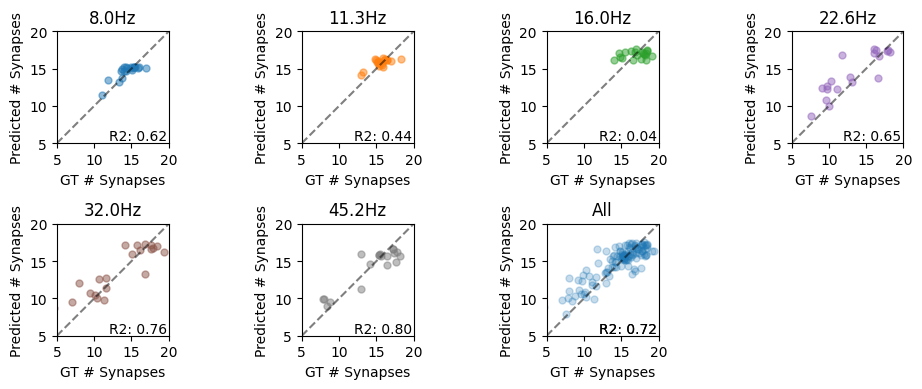

In [18]:
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)

Best RF score: 0.697, R2 on test set: 0.467
8.0Hz, 1043 samples, R2: 0.625, RMSE: 0.813
11.3Hz, 1009 samples, R2: 0.479, RMSE: 0.817
16.0Hz, 979 samples, R2: -0.014, RMSE: 1.476
22.6Hz, 953 samples, R2: 0.654, RMSE: 2.040
32.0Hz, 947 samples, R2: 0.766, RMSE: 2.002
45.2Hz, 970 samples, R2: 0.805, RMSE: 1.952
All data, 5901 samples, R2: 0.762, RMSE: 1.606


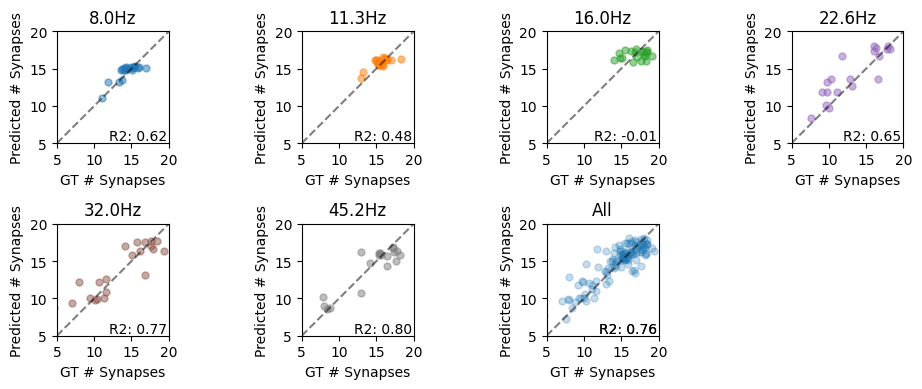

In [19]:
# Deeper trees
rf_pipeline_all_features = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "rf",
            RandomForestRegressor(
                random_state=1,
                n_estimators=50,
                min_samples_split=30,
                min_samples_leaf=2,
                max_features=0.5,
                max_depth=30,
            ),
        ),
    ]
)
rf_pipeline_all_features.fit(X_train, y_train)
r2 = rf_pipeline_all_features.score(X_test, y_test)
print(
    f"Best RF score: {rf_pipeline_all_features.score(X_train, y_train):.3f}, R2 on test set: {r2:.3f}"
)
train_plot_result_frequency_grouped(
    final_clean_strained, rf_pipeline_all_features
)

# XGBoost

In [20]:
from sklearn.model_selection import GridSearchCV
import multiprocessing
import xgboost as xgb

clf_params = {
    "clf__n_estimators": [25, 50, 100, 150, 200, 300],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best XGB params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best XGB score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
xgb_model = clf_search.best_estimator_

Best XGB params: {'clf__max_depth': 4, 'clf__n_estimators': 25}
Best XGB score: 0.422, R2 on test set: 0.566


8.0Hz, 1043 samples, R2: 0.605, RMSE: 0.835
11.3Hz, 1009 samples, R2: 0.443, RMSE: 0.845
16.0Hz, 979 samples, R2: 0.041, RMSE: 1.436
22.6Hz, 953 samples, R2: 0.530, RMSE: 2.378
32.0Hz, 947 samples, R2: 0.823, RMSE: 1.742
45.2Hz, 970 samples, R2: 0.884, RMSE: 1.505
All data, 5901 samples, R2: 0.770, RMSE: 1.581


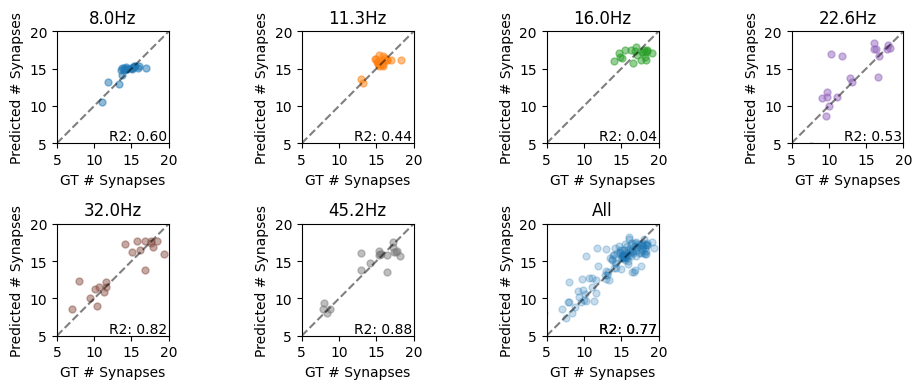

In [21]:
train_plot_result_frequency_grouped(final_clean_strained, xgb_model)

In [22]:
final_clean_strained_70 = final_clean_strained[
    final_clean_strained["Level(dB)"] == 70
]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Frequency(kHz)", "Strain (binary)"]
log_features = [
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]
no_noise_features = num_features + cat_features + log_features + minmax_features

X = final_clean_strained_70[
    num_features + cat_features + log_features + minmax_features
]
y = final_clean_strained_70["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[final_clean_strained_70.DataGroup != "Test"],
    X[final_clean_strained_70.DataGroup == "Test"],
    y[final_clean_strained_70.DataGroup != "Test"],
    y[final_clean_strained_70.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
        ("minmax_scale", MinMaxScaler(), minmax_features),
    ]
)

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
Best RF score: 0.234, R2 on test set: 0.314
8.0Hz, 1043 samples, R2: 0.634, RMSE: 0.803
11.3Hz, 1009 samples, R2: 0.275, RMSE: 0.965
16.0Hz, 979 samples, R2: 0.094, RMSE: 1.396
22.6Hz, 953 samples, R2: 0.366, RMSE: 2.763
32.0Hz, 947 samples, R2: 0.506, RMSE: 2.908
45.2Hz, 970 samples, R2: 0.490, RMSE: 3.154
All data, 5901 samples, R2: 0.569, RMSE: 2.162


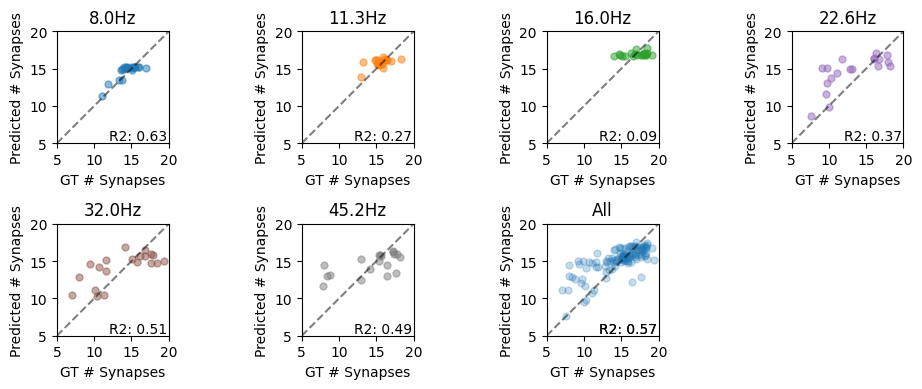

In [23]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 250, 500],
    "rf__max_depth": [5, 10, 20, 30, 40],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(random_state=1)),
    ]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model_no_noise = rf_search.best_estimator_
train_plot_result_frequency_grouped(
    final_clean_strained, best_rf_model_no_noise
)

In [24]:
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Frequency(kHz)"]
log_features = [
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]

abr_features = num_features + cat_features + log_features

X = final_clean_strained_70[num_features + cat_features + log_features]
y = final_clean_strained_70["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[final_clean_strained_70.DataGroup != "Test"],
    X[final_clean_strained_70.DataGroup == "Test"],
    y[final_clean_strained_70.DataGroup != "Test"],
    y[final_clean_strained_70.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
Best RF score: 0.199, R2 on test set: 0.225
8.0Hz, 1043 samples, R2: -0.024, RMSE: 1.343
11.3Hz, 1009 samples, R2: -0.022, RMSE: 1.145
16.0Hz, 979 samples, R2: 0.065, RMSE: 1.418
22.6Hz, 953 samples, R2: 0.364, RMSE: 2.767
32.0Hz, 947 samples, R2: 0.354, RMSE: 3.325
45.2Hz, 970 samples, R2: 0.406, RMSE: 3.403
All data, 5901 samples, R2: 0.457, RMSE: 2.427


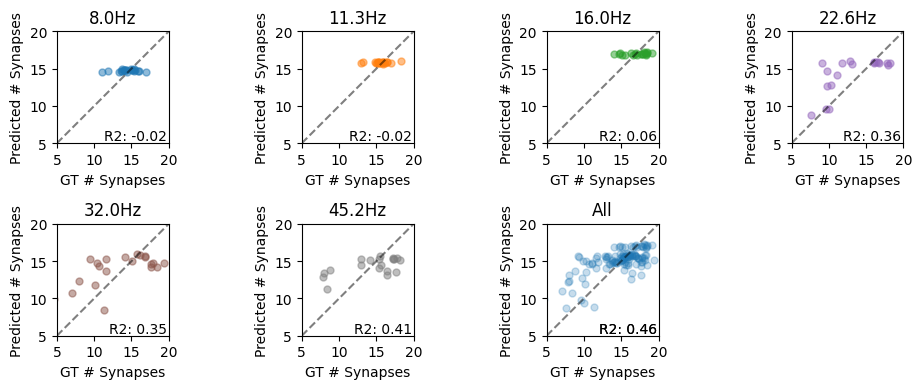

In [25]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 250, 500],
    "rf__max_depth": [5, 10, 20, 30, 40],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(random_state=1)),
    ]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model_abr = rf_search.best_estimator_
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model_abr)

In [26]:
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Noise_pred", "Frequency(kHz)"]
log_features = [
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]

abr_noise_pred_features = (
    num_features + cat_features + log_features + minmax_features
)

X = final_clean_strained_70[num_features + cat_features + log_features]
y = final_clean_strained_70["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[final_clean_strained_70.DataGroup != "Test"],
    X[final_clean_strained_70.DataGroup == "Test"],
    y[final_clean_strained_70.DataGroup != "Test"],
    y[final_clean_strained_70.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
Best RF score: 0.432, R2 on test set: 0.450
8.0Hz, 1043 samples, R2: -0.001, RMSE: 1.328
11.3Hz, 1009 samples, R2: 0.014, RMSE: 1.124
16.0Hz, 979 samples, R2: 0.172, RMSE: 1.334
22.6Hz, 953 samples, R2: 0.594, RMSE: 2.210
32.0Hz, 947 samples, R2: 0.594, RMSE: 2.634
45.2Hz, 970 samples, R2: 0.441, RMSE: 3.300
All data, 5901 samples, R2: 0.585, RMSE: 2.122


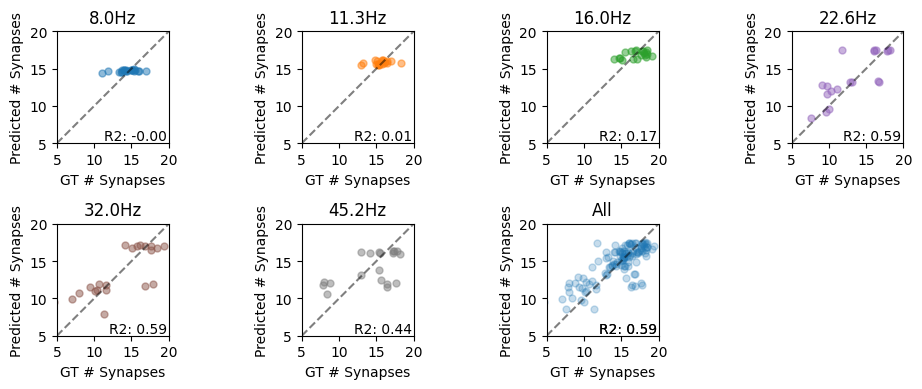

In [27]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 250, 500],
    "rf__max_depth": [5, 10, 20, 30, 40],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(random_state=1)),
    ]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model_abr_noise_pred = rf_search.best_estimator_
train_plot_result_frequency_grouped(
    final_clean_strained, best_rf_model_abr_noise_pred
)

In [28]:
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Frequency(kHz)", "Strain (binary)", "Noise_pred"]
log_features = [
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]

X = final_clean_strained_70[num_features + cat_features + log_features]
y = final_clean_strained_70["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[final_clean_strained_70.DataGroup != "Test"],
    X[final_clean_strained_70.DataGroup == "Test"],
    y[final_clean_strained_70.DataGroup != "Test"],
    y[final_clean_strained_70.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
Best RF score: 0.446, R2 on test set: 0.484
8.0Hz, 1043 samples, R2: 0.451, RMSE: 0.983
11.3Hz, 1009 samples, R2: 0.345, RMSE: 0.917
16.0Hz, 979 samples, R2: 0.154, RMSE: 1.349
22.6Hz, 953 samples, R2: 0.553, RMSE: 2.320
32.0Hz, 947 samples, R2: 0.611, RMSE: 2.578
45.2Hz, 970 samples, R2: 0.476, RMSE: 3.195
All data, 5901 samples, R2: 0.611, RMSE: 2.054


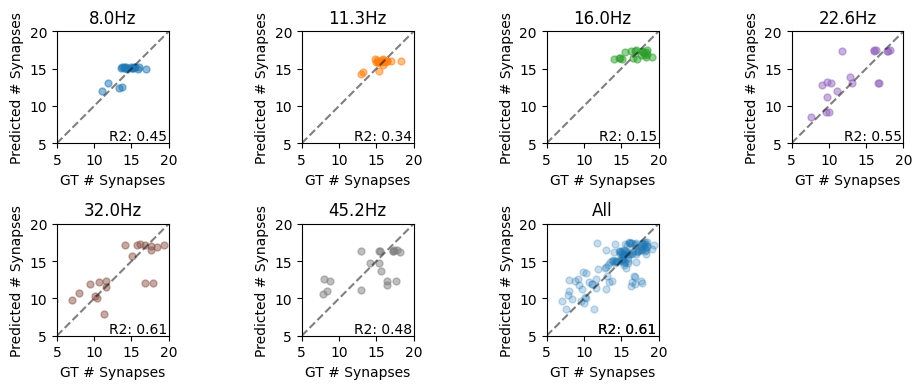

In [29]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 250, 500],
    "rf__max_depth": [5, 10, 20, 30, 40],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(random_state=1)),
    ]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_
train_plot_result_frequency_grouped(final_clean_strained, best_rf_model)

In [30]:
final_clean_strained_70 = final_clean_strained[
    final_clean_strained["Level(dB)"] == 70
]
final_clean_strained_70 = split_by_mouse(final_clean_strained_70)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"]
cat_features = ["Frequency(kHz)", "Strain (binary)", "Noise_pred"]
log_features = [
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Time (hrs)"]

extra_abr_noise_pred_features = (
    num_features + cat_features + log_features + minmax_features
)

X = final_clean_strained_70[extra_abr_noise_pred_features]
y = final_clean_strained_70["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[final_clean_strained_70.DataGroup != "Test"],
    X[final_clean_strained_70.DataGroup == "Test"],
    y[final_clean_strained_70.DataGroup != "Test"],
    y[final_clean_strained_70.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
        ("minmax_scale", MinMaxScaler(), minmax_features),
    ]
)

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 15, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': 20}
Best RF score: 0.455, R2 on test set: 0.479
8.0Hz, 1043 samples, R2: 0.610, RMSE: 0.829
11.3Hz, 1009 samples, R2: 0.307, RMSE: 0.943
16.0Hz, 979 samples, R2: 0.106, RMSE: 1.386
22.6Hz, 953 samples, R2: 0.565, RMSE: 2.288
32.0Hz, 947 samples, R2: 0.669, RMSE: 2.379
45.2Hz, 970 samples, R2: 0.537, RMSE: 3.005
All data, 5901 samples, R2: 0.632, RMSE: 1.999


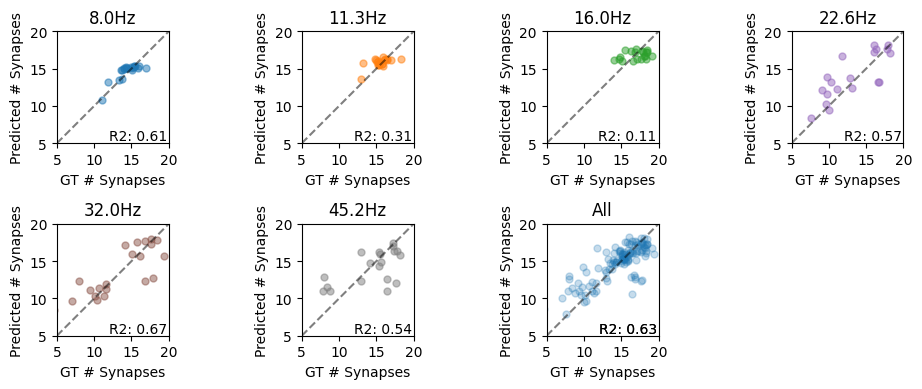

In [31]:
rf_params = {
    "rf__n_estimators": [25, 30, 50, 100, 150, 250, 500],
    "rf__max_depth": [5, 10, 20, 30, 40],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("rf", RandomForestRegressor(random_state=1)),
    ]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model_noise_pred = rf_search.best_estimator_
train_plot_result_frequency_grouped(
    final_clean_strained, best_rf_model_noise_pred
)

# Compare low frequencies

In [32]:
def plot_results(ax, x, y, alpha=0.2, markersize=5, color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    ax.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    ax.plot([5, 20], [5, 20], "k--", alpha=0.5)
    ax.axis("square")
    ax.set_xticks(np.arange(5, 21, 5))
    ax.set_yticks(np.arange(5, 21, 5))
    ax.set_xlim(5, 20)
    ax.set_ylim(5, 20)


def train_plot_result_frequency_grouped(
    df_list, pipelines, feature_list, freqs, labels, colors, figsize=(10, 4)
):

    fig, ax = plt.subplots(
        len(freqs),
        len(pipelines),
        sharey=True,
        figsize=figsize,
        layout="constrained",
    )
    fig.supxlabel("GT # Synapses")
    fig.supylabel("Predicted # Synapses")

    color_palette = plt.cm.get_cmap("tab10", 6 + 3)

    for i, pipeline in zip(range(len(pipelines)), pipelines):
        df = df_list[i]
        # df = split_by_mouse(df)

        # iterate over dB levels:
        for j, frq in zip(range(len(freqs)), freqs):
            features = feature_list[i]
            data = df[df["Frequency(kHz)"] == frq]
            X = data[features]
            y = data["SynapsesPerIHC"]
            X_train1, X_test1, y_train1, y_test1 = (
                X[data.DataGroup != "Test"],
                X[data.DataGroup == "Test"],
                y[data.DataGroup != "Test"],
                y[data.DataGroup == "Test"],
            )
            if len(X_train1) > 0 and len(X_test1) > 0:
                pipeline.fit(X_train1, y_train1)
                test = data[data.DataGroup == "Test"].copy()
                test["preds"] = pipeline.predict(X_test1)
                grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
                    {"SynapsesPerIHC": "mean", "preds": "mean"}
                )
                r2 = r2_score(
                    grouped_preds["SynapsesPerIHC"], grouped_preds["preds"]
                )
                rmse = np.sqrt(
                    np.mean(
                        (
                            grouped_preds["SynapsesPerIHC"]
                            - grouped_preds["preds"]
                        )
                        ** 2
                    )
                )
                print(
                    f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
                )
                plot_results(
                    ax[j, i],
                    grouped_preds["SynapsesPerIHC"],
                    grouped_preds["preds"],
                    color=color_palette(colors[j]),
                    alpha=0.5,
                )
                # show R2 in lower right corner of plot:
                ax[j, i].text(
                    19.75,
                    5,
                    f"R2: {r2:.2f}",
                    fontsize=10,
                    horizontalalignment="right",
                    verticalalignment="bottom",
                )
                ax[j, 0].set_ylabel(f"{frq}Hz")
            ax[0, i].set_title(labels[i])

In [33]:
num_features = ["Noise"]
cat_features = ["Frequency(kHz)"]
log_features = []
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if c.startswith(f"{col}_{i}")]
        num_features.extend(cols)
concat_noise_features = num_features + cat_features + log_features

8.0Hz, 1043 samples, R2: 0.625, RMSE: 0.813
11.3Hz, 1009 samples, R2: 0.479, RMSE: 0.817
16.0Hz, 979 samples, R2: -0.014, RMSE: 1.476
8.0Hz, 1043 samples, R2: 0.634, RMSE: 0.803
11.3Hz, 1009 samples, R2: 0.275, RMSE: 0.965
16.0Hz, 979 samples, R2: 0.094, RMSE: 1.396
8.0Hz, 1043 samples, R2: -0.024, RMSE: 1.343
11.3Hz, 1009 samples, R2: -0.022, RMSE: 1.145
16.0Hz, 979 samples, R2: 0.065, RMSE: 1.418
8.0Hz, 1043 samples, R2: 0.610, RMSE: 0.829
11.3Hz, 1009 samples, R2: 0.307, RMSE: 0.943
16.0Hz, 979 samples, R2: 0.106, RMSE: 1.386
8.0Hz, 1043 samples, R2: -0.001, RMSE: 1.328
11.3Hz, 1009 samples, R2: 0.014, RMSE: 1.124
16.0Hz, 979 samples, R2: 0.172, RMSE: 1.334


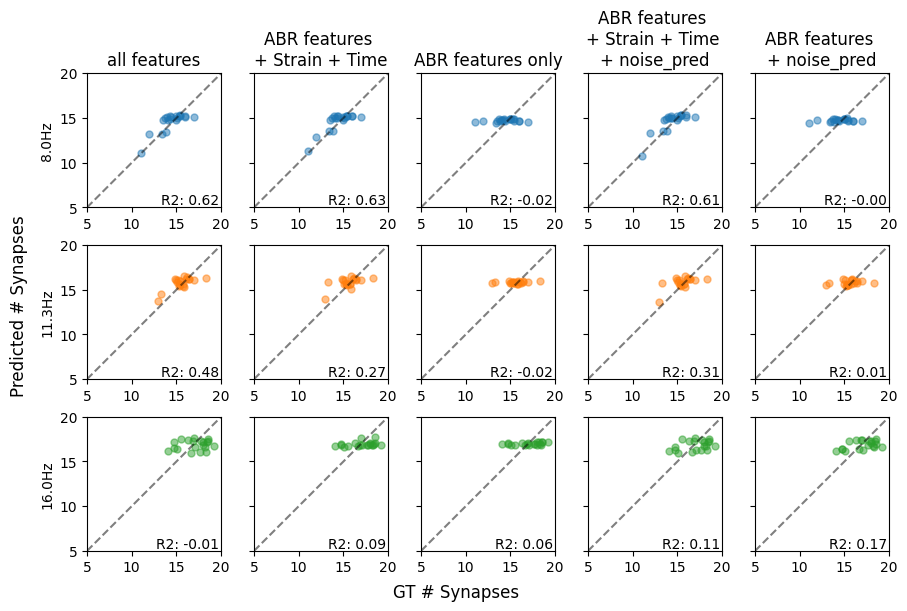

In [34]:
train_plot_result_frequency_grouped(
    [final_clean_strained] * 5,
    [
        rf_pipeline_all_features,
        best_rf_model_no_noise,
        best_rf_model_abr,
        best_rf_model_noise_pred,
        best_rf_model_abr_noise_pred,
    ],
    [
        all_features,
        no_noise_features,
        abr_features,
        extra_abr_noise_pred_features,
        abr_noise_pred_features,
    ],
    [8.0, 11.3, 16.0],
    [
        "all features",
        "ABR features \n+ Strain + Time",
        "ABR features only",
        "ABR features \n+ Strain + Time \n+ noise_pred",
        "ABR features \n+ noise_pred",
    ],
    [0, 1, 2],
    (9, 6),
)

8.0Hz, 1043 samples, R2: 0.625, RMSE: 0.813
11.3Hz, 1009 samples, R2: 0.479, RMSE: 0.817
16.0Hz, 979 samples, R2: -0.014, RMSE: 1.476
8.0Hz, 1043 samples, R2: 0.634, RMSE: 0.803
11.3Hz, 1009 samples, R2: 0.275, RMSE: 0.965
16.0Hz, 979 samples, R2: 0.094, RMSE: 1.396
8.0Hz, 1043 samples, R2: -0.024, RMSE: 1.343
11.3Hz, 1009 samples, R2: -0.022, RMSE: 1.145
16.0Hz, 979 samples, R2: 0.065, RMSE: 1.418
8.0Hz, 1043 samples, R2: 0.610, RMSE: 0.829
11.3Hz, 1009 samples, R2: 0.307, RMSE: 0.943
16.0Hz, 979 samples, R2: 0.106, RMSE: 1.386
8.0Hz, 1043 samples, R2: -0.001, RMSE: 1.328
11.3Hz, 1009 samples, R2: 0.014, RMSE: 1.124
16.0Hz, 979 samples, R2: 0.172, RMSE: 1.334
8.0Hz, 102 samples, R2: -0.142, RMSE: 1.083
11.3Hz, 103 samples, R2: -0.237, RMSE: 1.254
16.0Hz, 103 samples, R2: -0.218, RMSE: 1.398
8.0Hz, 102 samples, R2: -0.073, RMSE: 1.050
11.3Hz, 103 samples, R2: -0.237, RMSE: 1.254
16.0Hz, 103 samples, R2: -0.144, RMSE: 1.355


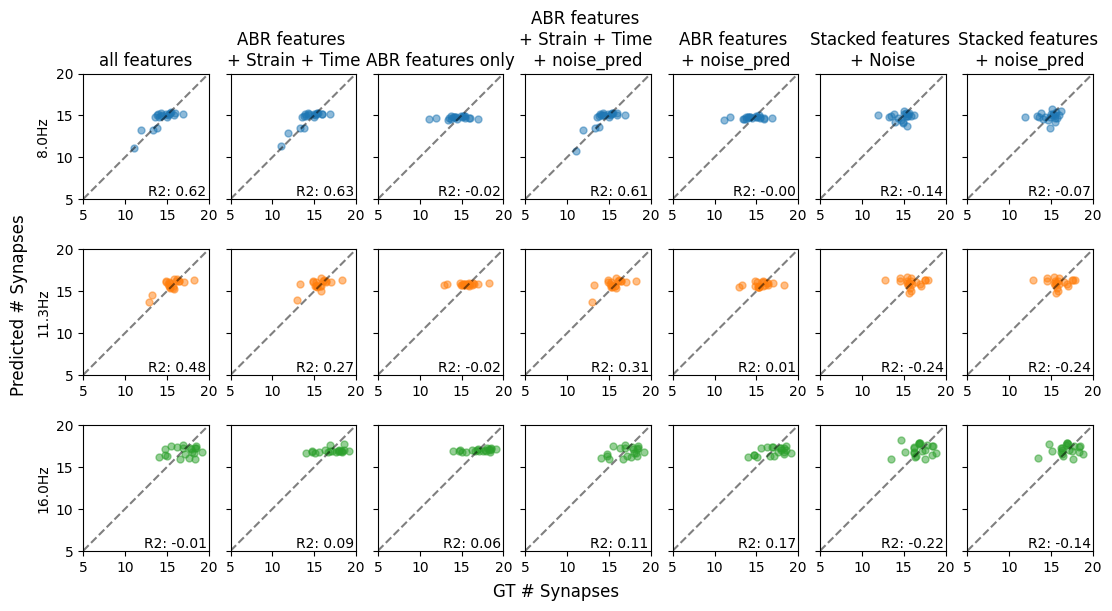

In [35]:
train_plot_result_frequency_grouped(
    [final_clean_strained] * 5 + [reformatted] * 2,
    [
        rf_pipeline_all_features,
        best_rf_model_no_noise,
        best_rf_model_abr,
        best_rf_model_noise_pred,
        best_rf_model_abr_noise_pred,
        concat_noise_xgb_model,
        concat_noise_pred_xgb_model,
    ],
    [
        all_features,
        no_noise_features,
        abr_features,
        extra_abr_noise_pred_features,
        abr_noise_pred_features,
        concat_noise_features,
        concat_noise_pred_features,
    ],
    [8.0, 11.3, 16.0],
    [
        "all features",
        "ABR features \n+ Strain + Time",
        "ABR features only",
        "ABR features \n+ Strain + Time \n+ noise_pred",
        "ABR features \n+ noise_pred",
        "Stacked features \n+ Noise",
        "Stacked features \n+ noise_pred",
    ],
    [0, 1, 2],
    (11, 6),
)

22.6Hz, 953 samples, R2: 0.530, RMSE: 2.378
32.0Hz, 947 samples, R2: 0.823, RMSE: 1.742
45.2Hz, 970 samples, R2: 0.884, RMSE: 1.505
22.6Hz, 953 samples, R2: 0.366, RMSE: 2.763
32.0Hz, 947 samples, R2: 0.506, RMSE: 2.908
45.2Hz, 970 samples, R2: 0.490, RMSE: 3.154
22.6Hz, 953 samples, R2: 0.364, RMSE: 2.767
32.0Hz, 947 samples, R2: 0.354, RMSE: 3.325
45.2Hz, 970 samples, R2: 0.406, RMSE: 3.403
22.6Hz, 953 samples, R2: 0.565, RMSE: 2.288
32.0Hz, 947 samples, R2: 0.669, RMSE: 2.379
45.2Hz, 970 samples, R2: 0.537, RMSE: 3.005
22.6Hz, 953 samples, R2: 0.594, RMSE: 2.210
32.0Hz, 947 samples, R2: 0.594, RMSE: 2.634
45.2Hz, 970 samples, R2: 0.441, RMSE: 3.300
22.6Hz, 103 samples, R2: 0.867, RMSE: 1.498
32.0Hz, 105 samples, R2: 0.574, RMSE: 2.953
45.2Hz, 100 samples, R2: 0.873, RMSE: 1.634
22.6Hz, 103 samples, R2: 0.766, RMSE: 1.990
32.0Hz, 105 samples, R2: 0.527, RMSE: 3.115
45.2Hz, 100 samples, R2: 0.479, RMSE: 3.312


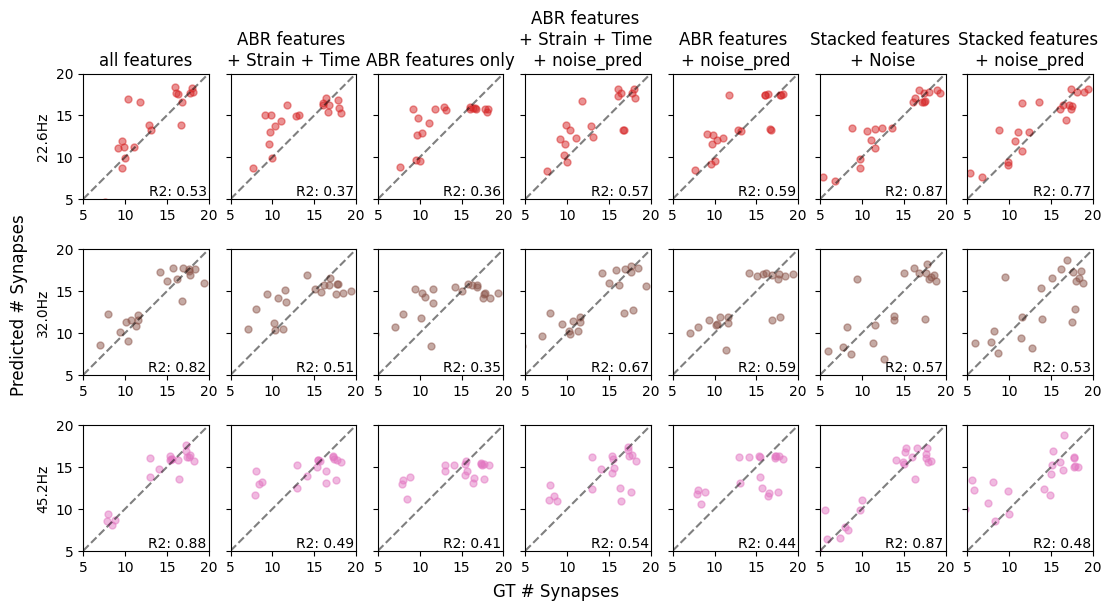

In [36]:
train_plot_result_frequency_grouped(
    [final_clean_strained] * 5 + [reformatted] * 2,
    [
        xgb_model,
        best_rf_model_no_noise,
        best_rf_model_abr,
        best_rf_model_noise_pred,
        best_rf_model_abr_noise_pred,
        concat_noise_xgb_model,
        concat_noise_pred_xgb_model,
    ],
    [
        all_features,
        no_noise_features,
        abr_features,
        extra_abr_noise_pred_features,
        abr_noise_pred_features,
        concat_noise_features,
        concat_noise_pred_features,
    ],
    [22.6, 32.0, 45.2],
    [
        "all features",
        "ABR features \n+ Strain + Time",
        "ABR features only",
        "ABR features \n+ Strain + Time \n+ noise_pred",
        "ABR features \n+ noise_pred",
        "Stacked features \n+ Noise",
        "Stacked features \n+ noise_pred",
    ],
    [3, 4, 5],
    (11, 6),
)

In [41]:
def plot_rmse(ax, x, y, alpha=0.2, markersize=5, color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    ax.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    ax.plot([5, 20], [5, 20], "k--", alpha=0.5)
    ax.axis("square")
    ax.set_xticks(np.arange(5, 21, 5))
    ax.set_yticks(np.arange(5, 21, 5))
    ax.set_xlim(5, 20)
    ax.set_ylim(5, 20)


def train_plot_rmse_frequency_grouped(
    df_list, pipelines, feature_list, freqs, labels, colors, figsize=(6, 6)
):

    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    fig.supxlabel("GT # Synapses")
    fig.supylabel("Predicted # Synapses")

    color_palette = plt.cm.get_cmap("tab10", 6 + 3)

    for i, pipeline in zip(range(len(pipelines)), pipelines):
        df = df_list[i]
        rmse_list = []
        # df = split_by_mouse(df)

        # iterate over dB levels:
        for j, frq in zip(range(len(freqs)), freqs):
            features = feature_list[i]
            data = df[df["Frequency(kHz)"] == frq]
            X = data[features]
            y = data["SynapsesPerIHC"]
            X_train1, X_test1, y_train1, y_test1 = (
                X[data.DataGroup != "Test"],
                X[data.DataGroup == "Test"],
                y[data.DataGroup != "Test"],
                y[data.DataGroup == "Test"],
            )
            if len(X_train1) > 0 and len(X_test1) > 0:
                pipeline.fit(X_train1, y_train1)
                test = data[data.DataGroup == "Test"].copy()
                test["preds"] = pipeline.predict(X_test1)
                grouped_preds = test.groupby(["Subject", "Frequency(kHz)"]).agg(
                    {"SynapsesPerIHC": "mean", "preds": "mean"}
                )
                r2 = r2_score(
                    grouped_preds["SynapsesPerIHC"], grouped_preds["preds"]
                )
                rmse = np.sqrt(
                    np.mean(
                        (
                            grouped_preds["SynapsesPerIHC"]
                            - grouped_preds["preds"]
                        )
                        ** 2
                    )
                )
                print(
                    f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}"
                )
                rmse_list.append(rmse)

            ax.plot(range(len(rmse_list)), rmse_list)
            ax.set_xticklabels(labels)

22.6Hz, 953 samples, R2: 0.530, RMSE: 2.378
32.0Hz, 947 samples, R2: 0.823, RMSE: 1.742
45.2Hz, 970 samples, R2: 0.884, RMSE: 1.505
22.6Hz, 953 samples, R2: 0.366, RMSE: 2.763
32.0Hz, 947 samples, R2: 0.506, RMSE: 2.908
45.2Hz, 970 samples, R2: 0.490, RMSE: 3.154
22.6Hz, 953 samples, R2: 0.364, RMSE: 2.767
32.0Hz, 947 samples, R2: 0.354, RMSE: 3.325
45.2Hz, 970 samples, R2: 0.406, RMSE: 3.403
22.6Hz, 953 samples, R2: 0.565, RMSE: 2.288
32.0Hz, 947 samples, R2: 0.669, RMSE: 2.379
45.2Hz, 970 samples, R2: 0.537, RMSE: 3.005
22.6Hz, 953 samples, R2: 0.594, RMSE: 2.210
32.0Hz, 947 samples, R2: 0.594, RMSE: 2.634
45.2Hz, 970 samples, R2: 0.441, RMSE: 3.300
22.6Hz, 103 samples, R2: 0.867, RMSE: 1.498
32.0Hz, 105 samples, R2: 0.574, RMSE: 2.953
45.2Hz, 100 samples, R2: 0.873, RMSE: 1.634
22.6Hz, 103 samples, R2: 0.766, RMSE: 1.990
32.0Hz, 105 samples, R2: 0.527, RMSE: 3.115
45.2Hz, 100 samples, R2: 0.479, RMSE: 3.312


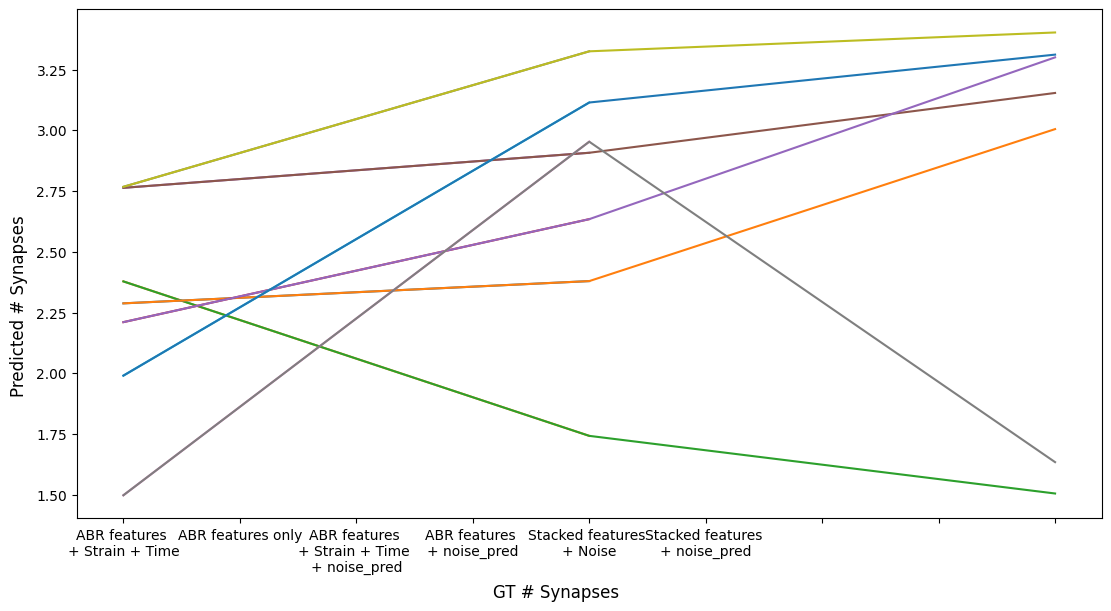

In [42]:
train_plot_rmse_frequency_grouped(
    [final_clean_strained] * 5 + [reformatted] * 2,
    [
        xgb_model,
        best_rf_model_no_noise,
        best_rf_model_abr,
        best_rf_model_noise_pred,
        best_rf_model_abr_noise_pred,
        concat_noise_xgb_model,
        concat_noise_pred_xgb_model,
    ],
    [
        all_features,
        no_noise_features,
        abr_features,
        extra_abr_noise_pred_features,
        abr_noise_pred_features,
        concat_noise_features,
        concat_noise_pred_features,
    ],
    [22.6, 32.0, 45.2],
    [
        "all features",
        "ABR features \n+ Strain + Time",
        "ABR features only",
        "ABR features \n+ Strain + Time \n+ noise_pred",
        "ABR features \n+ noise_pred",
        "Stacked features \n+ Noise",
        "Stacked features \n+ noise_pred",
    ],
    [3, 4, 5],
    (11, 6),
)